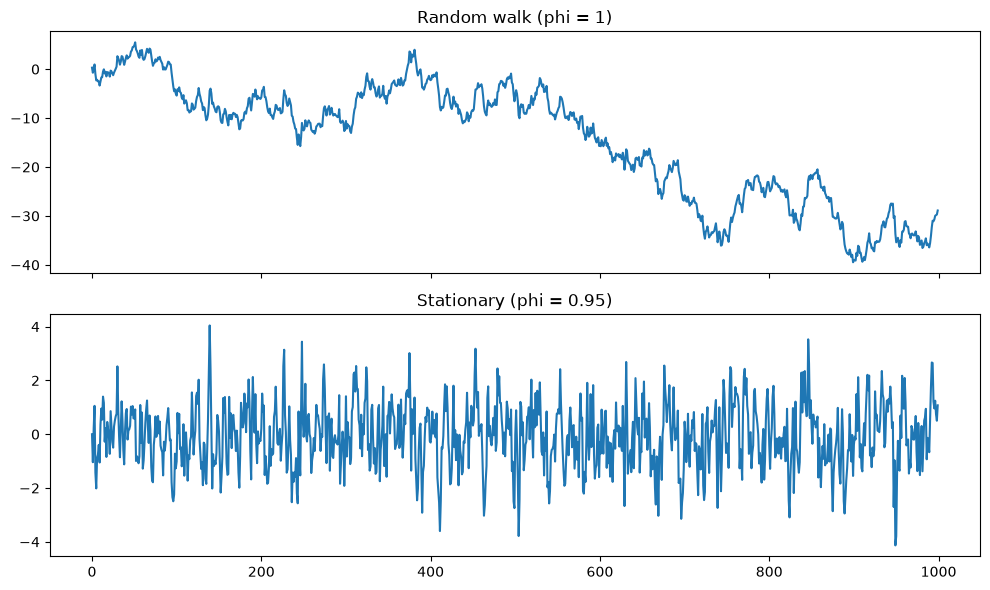

In [3]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)   # fixed seed → reproducible results
n = 1000
shocks = rng.normal(0, 1, n)      # the same random noise feeds both series

# Random walk: x_t = x_{t-1} + shock  (phi = 1, no spring)
random_walk = np.cumsum(shocks)

# Stationary: x_t = phi * x_{t-1} + shock  (phi < 1, spring present)
phi = 0.5
stationary = np.zeros(n)
for t in range(1, n):
    stationary[t] = phi * stationary[t - 1] + shocks[t]

fig, ax = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
ax[0].plot(random_walk);  ax[0].set_title("Random walk (phi = 1)")
ax[1].plot(stationary);   ax[1].set_title("Stationary (phi = 0.95)")
plt.tight_layout(); plt.show()

In [4]:
def final_values(phi, n_paths=500, n=1000):
    finals = []
    for _ in range(n_paths):
        x = 0.0
        for s in rng.normal(0, 1, n):
            x = phi * x + s
        finals.append(x)
    return np.std(finals)

print("spread of end values, random walk:", final_values(1.0))   # about 31 (√1000)
print("spread of end values, phi = 0.95: ", final_values(0.95))  # about 3.2

spread of end values, random walk: 30.992403270139715
spread of end values, phi = 0.95:  2.984766968895647


In [8]:
import os
from dotenv import load_dotenv
from web3 import Web3

load_dotenv(override=True)
for name in ["ARBITRUM_RPC_URL", "ARBITRUM_SEPOLIA_RPC_URL"]:
    url = os.environ[name]
    print(name, "| placeholder left in:", "YOUR_API_KEY" in url,
          "| host:", url.split("/")[2], "| key length:", len(url.split("/")[-1]))
    w3 = Web3(Web3.HTTPProvider(url))
    try:
        print("   chain id:", w3.eth.chain_id, "| block:", w3.eth.block_number)
    except Exception as e:
        print("   failed:", type(e).__name__)

ARBITRUM_RPC_URL | placeholder left in: False | host: arb-mainnet.g.alchemy.com | key length: 26
   chain id: 42161 | block: 511433445
ARBITRUM_SEPOLIA_RPC_URL | placeholder left in: False | host: arb-sepolia.g.alchemy.com | key length: 26
   chain id: 421614 | block: 315473684
